# Tabular Deep Learning - ETF Rotation

TabM applies rank-1 adapter MLP ensembles to the same flat feature matrix used
by Ridge and GBM, testing whether a neural ensemble learns cross-asset feature
interactions that linear models and tree splits miss. For ETFs spanning 9 asset
classes, the question is whether adapter-style ensembling captures interactions
(e.g., equity momentum predicting bond rotation) that lift cross-sectional IC
above the linear and GBM baselines from `06_linear` and `07_gbm`.

**Learning Objectives**:
- Read TabM walk-forward checkpoint results from the frozen results registry
- Compare TabM configurations (small/medium/large) on cross-asset ETF features
- Tune the checkpoint (epoch count) on validation via a shared grid, holdout sealed
- Place tabular DL against the linear and GBM baselines on the same cross-section

**Book Reference**: Chapter 12, Section 12.3 (Deep Learning Alternatives)

**Prerequisites**: `03_financial_features.py`, `04_temporal.py`, [`05_evaluation`](05_evaluation.ipynb)

In [1]:
"""Tabular DL Grid Search - TabM via walk-forward CV, results from the frozen registry."""

import sqlite3
import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import yaml

from case_studies.utils.registry import (
    build_training_spec,
    load_prediction_metrics,
    load_prediction_sets,
    training_hash_from_spec,
    training_run_status,
)
from case_studies.utils.tabular_dl import run_tabm_cv
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "etfs"
PRIMARY_LABEL = ""  # Read from setup.yaml if empty
MAX_SYMBOLS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
N_EPOCHS = 100
BATCH_SIZE = 4096
MAX_FOLDS = 0

In [3]:
# Resolve config from setup.yaml
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]
    print(f"Label from setup.yaml: {PRIMARY_LABEL}")
else:
    print(f"Label override: {PRIMARY_LABEL}")

tdl_config = setup.get("modeling", {}).get("tabular_dl", {})
MODELS = tdl_config.get("models", ["tabm"])
DEVICE = tdl_config.get("device", "gpu")

device_str = "cuda" if DEVICE == "gpu" and torch.cuda.is_available() else "cpu"
print(f"Case study: {CASE_STUDY_ID}")
print(f"Device: {device_str} | Models: {MODELS}")
print(f"Retrain epoch budget: {N_EPOCHS} | Batch: {BATCH_SIZE} (used only for uncached configs)")

Label from setup.yaml: fwd_ret_21d
Case study: etfs
Device: cuda | Models: ['tabm']
Retrain epoch budget: 100 | Batch: 4096 (used only for uncached configs)


## 1. Load Artifacts

Load pre-computed financial features (Ch8), temporal features (Ch9), labels,
and generate CV splits using the shared modeling infrastructure.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"
splits = mds.splits
if MAX_FOLDS:
    splits = splits[:MAX_FOLDS]
n_features = len(feature_names)

print(f"Dataset: {len(dataset):,} rows × {n_features} features")
print(f"Label: {label_col} | Date: {date_col} | Entity: {entity_col}")
for s in splits:
    print(
        f"  Fold {s['fold']}: train {str(s['train_start'])[:10]}\u2192{str(s['train_end'])[:10]}  "
        f"val {str(s['val_start'])[:10]}\u2192{str(s['val_end'])[:10]}"
    )

Dataset: 394,233 rows × 71 features
Label: fwd_ret_21d | Date: timestamp | Entity: symbol
  Fold 0: train 2012-12-28→2022-11-28  val 2022-12-29→2023-12-29
  Fold 1: train 2011-12-27→2021-11-26  val 2021-12-29→2022-12-28
  Fold 2: train 2010-12-28→2020-11-25  val 2020-12-29→2021-12-28
  Fold 3: train 2009-12-28→2019-11-26  val 2019-12-30→2020-12-28
  Fold 4: train 2008-12-26→2018-11-26  val 2018-12-28→2019-12-27
  Fold 5: train 2007-12-27→2017-11-24  val 2017-12-27→2018-12-27
  Fold 6: train 2007-01-03→2016-11-23  val 2016-12-27→2017-12-26
  Fold 7: train 2007-01-03→2015-11-24  val 2015-12-28→2016-12-23


## 1b. Data Diagnostics

In [5]:
dataset_pd = dataset.to_pandas()

label_nans = dataset_pd[label_col].isna().sum()
feat_nan_rate = dataset_pd[feature_names].isna().mean().mean()
n_entities = dataset_pd[entity_col].nunique()

print(f"Entities: {n_entities}")
print(f"Label NaN: {label_nans:,} / {len(dataset_pd):,} ({label_nans / len(dataset_pd):.1%})")
print(f"Feature NaN rate: {feat_nan_rate:.1%}")

Entities: 99
Label NaN: 0 / 394,233 (0.0%)
Feature NaN rate: 7.1%


## 2. Build Grid

Three TabM configurations by capacity: small (64 hidden x 4 members), medium
(128 x 8), large (256 x 16). All share the same 25-epoch checkpoint grid, so
their peak-checkpoint ICs are directly comparable.

In [6]:
tabdl_configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "tabular_dl")

# Apply Papermill training overrides. N_EPOCHS/BATCH_SIZE are part of the training
# spec hash, so they select which registered run to read: the frozen registry was
# built at N_EPOCHS=100, and changing it here would miss the cache and trigger a
# fresh GPU train that rewrites the registry. Keep the default for a cached read.
for cfg in tabdl_configs:
    if cfg.get("n_epochs", 100) != N_EPOCHS:
        cfg["n_epochs"] = N_EPOCHS
    if cfg.get("batch_size", 4096) != BATCH_SIZE:
        cfg["batch_size"] = BATCH_SIZE

print(f"Grid: {len(tabdl_configs)} configs × {len(splits)} folds (checkpoints read from registry)")
for cfg in tabdl_configs:
    name = cfg["config_name"]
    params = cfg.get("params", {})
    if name.startswith("tabpfn"):
        print(f"  {name:15s}  max_samples={params.get('max_samples', 2000)}")
    else:
        print(
            f"  {name:15s}  hidden={params['hidden_dim']}  "
            f"members={params['n_members']}  dropout={params['dropout']}"
        )

Grid: 3 configs × 8 folds (checkpoints read from registry)


  tabm_s           hidden=64  members=4  dropout=0.1
  tabm_m           hidden=128  members=8  dropout=0.1
  tabm_l           hidden=256  members=16  dropout=0.1


## 3. Load Registered Checkpoints

The results registry (`run_log/registry.db`) is the frozen source of truth for
this case study. Each config was trained walk-forward with cross-sectional IC
evaluated at 25-epoch checkpoints, and every checkpoint is stored as a
prediction set with its validation IC. Here we read those checkpoints back from
the registry rather than retraining: on a cached checkout no GPU work happens
and the frozen registry is never rewritten. Only a config with no registered
validation predictions triggers a fresh `run_tabm_cv` train.

In [7]:
def _rebuild_from_registry(cfg: dict) -> dict | None:
    """Rebuild one config's checkpoint curve + peak IC from the frozen registry.

    Returns None if the config has no complete registered validation set (a
    fresh reader who deleted the registry), in which case it is queued for
    training below.
    """
    spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(splits),
        n_epochs=cfg.get("n_epochs"),
    )
    status = training_run_status(CASE_STUDY_ID, spec)
    t_hash = training_hash_from_spec(spec)
    psets = load_prediction_sets(CASE_STUDY_ID, training_hash=t_hash, split=PREDICTION_SPLIT)
    if not status.complete or psets.is_empty():
        return None

    curve = []
    for row in psets.iter_rows(named=True):
        m = load_prediction_metrics(CASE_STUDY_ID, prediction_hash=row["prediction_hash"])
        if m.is_empty():
            continue
        nd = m["ic_n_days"][0]
        curve.append(
            {
                "config": cfg["config_name"],
                "epoch": int(row["checkpoint_value"]),
                "ic_mean": float(m["ic_mean"][0]),
                "ic_n_days": float(nd) if nd is not None else float("nan"),
                "prediction_hash": row["prediction_hash"],
            }
        )
    curve.sort(key=lambda c: c["epoch"])
    # Peak-checkpoint selection: the tree-count analogue is the epoch count, tuned
    # on validation over the shared 25-epoch grid. Holdout is never touched here.
    peak = max(curve, key=lambda c: c["ic_mean"])
    return {
        "config_name": cfg["config_name"],
        "best_epoch": peak["epoch"],
        "best_ic": peak["ic_mean"],
        "ic_n_days": peak["ic_n_days"],
        "best_prediction_hash": peak["prediction_hash"],
        "curve": curve,
        "cached": True,
    }


grid_results = []
to_train = []
for cfg in tabdl_configs:
    rebuilt = _rebuild_from_registry(cfg)
    if rebuilt is not None:
        grid_results.append(rebuilt)
        print(
            f"  {rebuilt['config_name']:10s}  epoch={rebuilt['best_epoch']:4d}  "
            f"IC={rebuilt['best_ic']:+.4f}  (cached)"
        )
    else:
        to_train.append(cfg)

# Uncached configs (none on the frozen registry) train via run_tabm_cv, which
# writes the registry. On a cached checkout `to_train` is empty, so no GPU work
# runs and the frozen registry stays byte-identical.
if to_train:
    print(f"\nTraining {len(to_train)} uncached config(s)...")
    fresh = run_tabm_cv(
        dataset_pd,
        splits,
        configs=to_train,
        n_features=n_features,
        feature_names=feature_names,
        label_col=label_col,
        date_col=date_col,
        entity_col=entity_col,
        device=device_str,
        save_dir=CASE_DIR / "run_log" / "training" / "tabular_dl",
        register=True,
        force_retrain=FORCE_RETRAIN,
        prediction_split=PREDICTION_SPLIT,
        case_study=CASE_STUDY_ID,
        notebook="08_tabular_dl",
        temporal_by_fold=mds.temporal_by_fold,
        temporal_keys=mds.temporal_keys,
        temporal_feature_names=mds.temporal_feature_names,
    )
    for r in fresh["grid_results"]:
        grid_results.append(
            {
                "config_name": r["config_name"],
                "best_epoch": r["best_epoch"],
                "best_ic": r["best_ic"],
                "ic_n_days": float("nan"),
                "best_prediction_hash": None,
                "curve": [
                    c
                    for c in fresh["all_learning_curves"].to_dicts()
                    if c["config"] == r["config_name"]
                ],
                "cached": False,
            }
        )

  tabm_s      epoch=  75  IC=+0.0182  (cached)
  tabm_m      epoch= 150  IC=+0.0092  (cached)
  tabm_l      epoch= 125  IC=+0.0341  (cached)


## 4. Grid Results

Configs are ranked by their validation IC. Each config's reported IC is its
**peak-checkpoint** value: for every config the epoch count is tuned on the
validation folds by scanning the same 25-epoch checkpoint grid and keeping the
checkpoint with the highest mean cross-sectional IC. Because all three configs
share the identical grid, this validation-based choice of training length is
comparable across the grid (it is the epoch-count analogue of early stopping)
and does not favor one config over another. The holdout is never touched here.

A full-coverage guard mirrors `06_linear`, `07_gbm`, and `13_model_analysis`:
a config that collapses to near-constant predictions on some folds produces no
cross-sectional IC on those validation dates, so its IC is measured on fewer
days (`ic_n_days` below the full-coverage maximum) and is not comparable. Such
configs are listed separately and excluded from the winner. On the frozen
registry all three TabM configs are full-coverage, so the guard is inert here.

In [8]:
grid_results.sort(
    key=lambda r: r["best_ic"] if np.isfinite(r["best_ic"]) else -np.inf, reverse=True
)

_finite_days = [r["ic_n_days"] for r in grid_results if np.isfinite(r.get("ic_n_days", np.nan))]
if _finite_days:
    _full_days = max(_finite_days)
    full_cov = [
        r
        for r in grid_results
        if np.isfinite(r.get("ic_n_days", np.nan)) and r["ic_n_days"] == _full_days
    ]
    partial_cov = [r for r in grid_results if r not in full_cov]
else:
    _full_days = None
    full_cov = grid_results
    partial_cov = []

best = full_cov[0] if full_cov else None
best_name = best["config_name"] if best else None
best_epoch = best["best_epoch"] if best else 0
best_ic = best["best_ic"] if best else float("nan")

print(f"{'Config':10s} {'Best Epoch':>10s} {'Peak IC':>10s} {'N Days':>8s}")
print("-" * 42)
for r in full_cov:
    marker = " *" if r is best else ""
    _nd = r.get("ic_n_days", np.nan)
    _nd_str = f"{int(_nd):>8d}" if np.isfinite(_nd) else f"{'n/a':>8s}"
    print(f"{r['config_name']:10s} {r['best_epoch']:10d} {r['best_ic']:+10.4f} {_nd_str}{marker}")

if partial_cov:
    print("\nPartial coverage (degenerate on some folds - excluded from ranking):")
    for r in partial_cov:
        _nd = r.get("ic_n_days", np.nan)
        _nd_str = f"{int(_nd)}" if np.isfinite(_nd) else "n/a"
        print(f"  {r['config_name']:10s}  IC={r['best_ic']:+.4f}  n_days={_nd_str}")

if best:
    print(f"\nBest (full coverage): {best_name} @ epoch {best_epoch} (IC={best_ic:+.4f})")


# Registry baselines from 06_linear (Ridge, full-coverage linear leader) and
# 07_gbm (leaves_7_mae) for the same label/split - read once for the comparison.
def _family_leader(family: str) -> tuple[str, float]:
    """Max peak-checkpoint validation IC for another model family, from the registry."""
    con = sqlite3.connect(CASE_DIR / "run_log" / "registry.db")
    try:
        q = """
        SELECT t.config_name, MAX(pm.ic_mean) AS mic
        FROM training_runs t
        JOIN prediction_sets ps ON ps.training_hash = t.training_hash
        JOIN prediction_metrics pm ON pm.prediction_hash = ps.prediction_hash
        WHERE t.family = ? AND t.label = ? AND ps.split = ?
          AND (pm.ic_n_days IS NULL OR pm.ic_n_days = (
              SELECT MAX(pm2.ic_n_days) FROM prediction_metrics pm2
              JOIN prediction_sets ps2 ON ps2.prediction_hash = pm2.prediction_hash
              JOIN training_runs t2 ON t2.training_hash = ps2.training_hash
              WHERE t2.family = t.family AND t2.label = t.label AND ps2.split = ps.split))
        GROUP BY t.config_name ORDER BY mic DESC LIMIT 1
        """
        row = con.execute(q, (family, label_col, PREDICTION_SPLIT)).fetchone()
    finally:
        con.close()
    return (row[0], float(row[1])) if row else ("n/a", float("nan"))


gbm_leader, gbm_ic = _family_leader("gbm")
lin_leader, lin_ic = _family_leader("linear")
print(f"\nBaselines - GBM: {gbm_leader} {gbm_ic:+.4f} | linear: {lin_leader} {lin_ic:+.4f}")

Config     Best Epoch    Peak IC   N Days
------------------------------------------
tabm_l            125    +0.0341     2016 *
tabm_s             75    +0.0182     2016
tabm_m            150    +0.0092     2016

Best (full coverage): tabm_l @ epoch 125 (IC=+0.0341)

Baselines - GBM: leaves_7_mae +0.0440 | linear: ridge_a1000000.0 +0.0420


### IC by configuration against the baselines

The bar chart ranks the three TabM configs by validation IC, with the
full-coverage GBM and linear leaders drawn as reference lines. The best TabM
config sits below both baselines: on this cross-section the neural ensemble
does not add cross-sectional IC over a shallow-tree GBM or a heavily
regularized linear model.

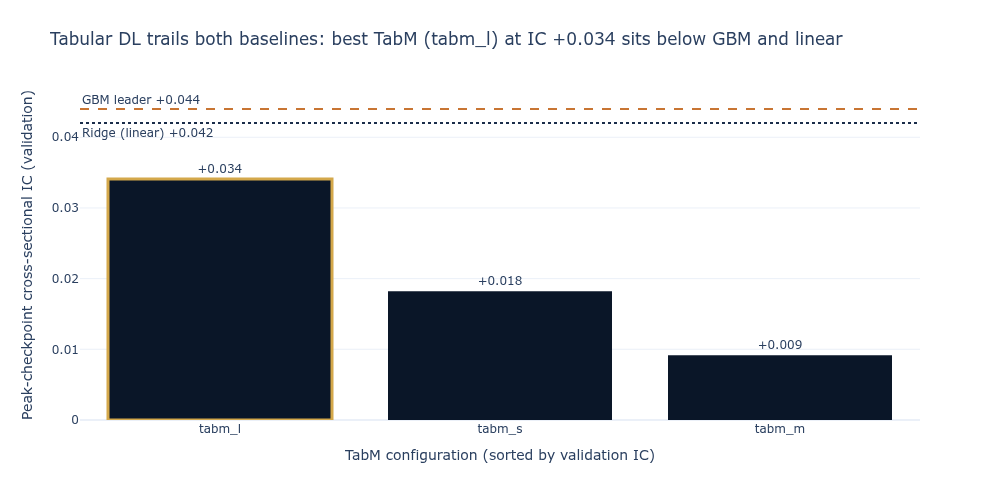

In [9]:
# Figure 1 - IC by TabM config, winner outlined, baselines as reference lines.
_names = [r["config_name"] for r in full_cov]
_ics = [r["best_ic"] for r in full_cov]
_line_w = [3 if n == best_name else 0 for n in _names]
fig_ic = go.Figure(
    go.Bar(
        x=_names,
        y=_ics,
        marker=dict(color=COLORS["blue"], line=dict(color=COLORS["amber"], width=_line_w)),
        text=[f"{v:+.3f}" for v in _ics],
        textposition="outside",
        cliponaxis=False,
        showlegend=False,
    )
)
if np.isfinite(gbm_ic):
    fig_ic.add_hline(
        y=gbm_ic,
        line=dict(color=COLORS["copper"], width=2, dash="dash"),
        annotation_text=f"GBM leader {gbm_ic:+.3f}",
        annotation_position="top left",
    )
if np.isfinite(lin_ic):
    fig_ic.add_hline(
        y=lin_ic,
        line=dict(color=COLORS["slate"], width=2, dash="dot"),
        annotation_text=f"Ridge (linear) {lin_ic:+.3f}",
        annotation_position="bottom left",
    )
fig_ic.update_layout(
    title=(
        f"Tabular DL trails both baselines: best TabM ({best_name}) at IC "
        f"{best_ic:+.3f} sits below GBM and linear"
    ),
    template="plotly_white",
    height=500,
    width=1000,
    margin=dict(t=90),
)
fig_ic.update_xaxes(title_text="TabM configuration (sorted by validation IC)")
fig_ic.update_yaxes(title_text="Peak-checkpoint cross-sectional IC (validation)")
fig_ic.show()

## 5. Learning Curves

Validation IC at each 25-epoch checkpoint traces how each config trains. The
winner is highlighted; the vertical line marks its selected epoch count. Only
`tabm_l` separates from the pack, jumping after 100 epochs to peak at 125;
`tabm_s` peaks early near 75 and drifts down, and `tabm_m` never clears the
other two. Capacity does not order cleanly here - the medium config is the
weakest of the three.

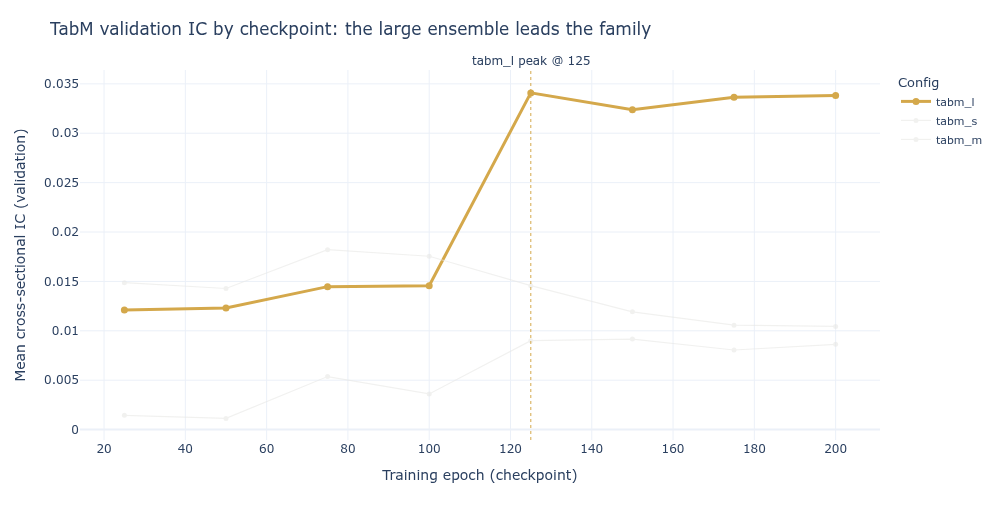

Config          50     100     150     200
tabm_l     +0.0123 +0.0146 +0.0324 +0.0338
tabm_s     +0.0143 +0.0176 +0.0119 +0.0104
tabm_m     +0.0011 +0.0036 +0.0092 +0.0086


In [10]:
all_curves = pl.DataFrame([c for r in grid_results for c in r["curve"]])
if all_curves.height > 0:
    # Figure 2 - checkpoint learning curves (IC vs epoch), winner highlighted.
    fig_lc = go.Figure()
    for r in grid_results:
        cfg_data = all_curves.filter(pl.col("config") == r["config_name"]).sort("epoch")
        if cfg_data.height == 0:
            continue
        is_winner = best is not None and r["config_name"] == best_name
        fig_lc.add_trace(
            go.Scatter(
                x=cfg_data["epoch"].to_list(),
                y=cfg_data["ic_mean"].to_list(),
                mode="lines+markers",
                name=r["config_name"],
                line=dict(
                    color=COLORS["amber"] if is_winner else COLORS["silver_muted"],
                    width=3 if is_winner else 1.2,
                ),
                marker=dict(size=7 if is_winner else 5),
                opacity=1.0 if is_winner else 0.6,
            )
        )
    if best is not None:
        fig_lc.add_vline(
            x=best_epoch,
            line=dict(color=COLORS["amber"], width=1, dash="dot"),
            annotation_text=f"{best_name} peak @ {best_epoch}",
            annotation_position="top",
        )
    fig_lc.update_layout(
        title="TabM validation IC by checkpoint: the large ensemble leads the family",
        template="plotly_white",
        height=520,
        width=1000,
        legend=dict(title="Config", font=dict(size=11)),
        margin=dict(t=70),
    )
    fig_lc.update_xaxes(title_text="Training epoch (checkpoint)")
    fig_lc.update_yaxes(title_text="Mean cross-sectional IC (validation)")
    fig_lc.show()

    # Compact checkpoint table for the exact values behind the curves.
    checkpoints = sorted(all_curves["epoch"].unique().to_list())
    display_cps = [cp for cp in checkpoints if cp % 50 == 0 or cp == checkpoints[-1]]

    print(f"{'Config':10s}", end="")
    for cp in display_cps:
        print(f" {cp:>7d}", end="")
    print()
    for r in grid_results:
        cfg_data = all_curves.filter(pl.col("config") == r["config_name"])
        print(f"{r['config_name']:10s}", end="")
        for cp in display_cps:
            row = cfg_data.filter(pl.col("epoch") == cp)
            print(f" {row['ic_mean'][0]:+7.4f}" if row.height > 0 else f" {'N/A':>7s}", end="")
        print()

## 6. Winner Fold Metrics

The winner's validation IC is the mean of its per-fold cross-sectional IC.
Reading the fold breakdown from the frozen registry shows how uneven that
average is: the headline IC rests on a few strong folds and turns negative on
the last two, a sign the tabular-DL edge is not stable across the walk-forward.

In [11]:
if best and best.get("best_prediction_hash"):
    con = sqlite3.connect(CASE_DIR / "run_log" / "registry.db")
    try:
        fold_rows = con.execute(
            "SELECT fold_id, ic, n_entities FROM fold_metrics "
            "WHERE prediction_hash = ? ORDER BY fold_id",
            (best["best_prediction_hash"],),
        ).fetchall()
    finally:
        con.close()
    print(f"Per-fold validation IC ({best_name} @ epoch {best_epoch}):")
    for fold_id, ic, n_ent in fold_rows:
        print(f"  Fold {fold_id}: IC={ic:+.4f}  n_entities={int(n_ent)}")
    _fold_mean = float(np.mean([r[1] for r in fold_rows])) if fold_rows else float("nan")
    print(f"\n  Mean fold IC: {_fold_mean:+.4f}  (registered peak IC: {best_ic:+.4f})")

Per-fold validation IC (tabm_l @ epoch 125):
  Fold 0: IC=+0.0149  n_entities=96
  Fold 1: IC=+0.0195  n_entities=97
  Fold 2: IC=+0.0609  n_entities=96
  Fold 3: IC=+0.0270  n_entities=97
  Fold 4: IC=+0.1129  n_entities=97
  Fold 5: IC=+0.0618  n_entities=96
  Fold 6: IC=-0.0120  n_entities=94
  Fold 7: IC=-0.0123  n_entities=90

  Mean fold IC: +0.0341  (registered peak IC: +0.0341)


## 7. Registered Predictions

Every checkpoint's validation predictions are already persisted in
`run_log/registry.db` and the backtest reads the winner's prediction set
directly. No retraining or re-saving happens on a cached checkout.

In [12]:
if best and best.get("best_prediction_hash"):
    _winner_set = load_prediction_sets(
        CASE_STUDY_ID,
        training_hash=None,
        split=PREDICTION_SPLIT,
    ).filter(pl.col("prediction_hash") == best["best_prediction_hash"])
    print(f"Winner prediction_hash: {best['best_prediction_hash']}")
    print(f"Registered checkpoints across the grid: {all_curves.height}")
    print(f"Winner set rows in registry: {_winner_set.height}")

Winner prediction_hash: 5d2793caff56
Registered checkpoints across the grid: 24
Winner set rows in registry: 1


## 8. Key Takeaways

- **Tabular DL underperforms both baselines here.** The best TabM config,
  `tabm_l`, tops the family at validation IC $\approx +0.034$ (peak near 125
  epochs), but that is below the GBM leader (`leaves_7_mae`, $\approx +0.044$
  from [`07_gbm`](07_gbm.ipynb)) and the full-coverage linear leader (Ridge at
  $\alpha = 10^6$, $\approx +0.042$ from [`06_linear`](06_linear.ipynb)). On this
  cross-section the neural ensemble's learned interactions do not lift IC above a
  shallow-tree GBM or a heavily regularized linear model.
- **The largest config wins, but capacity is not monotonic.** `tabm_l`
  ($\approx +0.034$) leads, yet `tabm_s` ($\approx +0.018$) beats the mid-sized
  `tabm_m` ($\approx +0.009$), so more members do not reliably buy more IC on this
  cross-section. Even the best config sits well below the linear and tree
  baselines: the whole family is weak here.
- **The edge is fold-fragile.** The winner's IC is carried by a few folds and
  goes negative on the last two, so the $+0.034$ is not a stable cross-sectional
  signal. The epoch count is tuned on the validation folds via the shared
  checkpoint grid, the analogue of early stopping; the holdout is untouched.

For flat-feature models the ETF cross-asset signal is largely linear and
already captured by Ridge and a shallow GBM. That motivates the temporal models
in Ch13: sequence architectures can exploit lead-lag structure across the 9
asset classes that no cross-sectional flat-feature model can see.

**Next**: [`09_dl_lstm`](09_dl_lstm.ipynb) tests whether sequential memory captures
momentum regime transitions that flat-feature models miss.
**Book**: Chapter 12.3 discusses when tabular DL does and does not beat GBMs.

In [13]:
print(f"\n{'=' * 60}")
print(f"Tabular DL Grid Search: {CASE_STUDY_ID}")
print(f"{'=' * 60}")
print(f"Features: {n_features}  |  Folds: {len(splits)}  |  Label: {label_col}")
print(f"Device: {device_str}")
print(f"Grid: {len(tabdl_configs)} configs ({', '.join(MODELS)})")
print(f"{'-' * 60}")
print(f"Best config: {best_name} @ epoch {best_epoch}")
print(f"Validation IC (cross-sectional): {best_ic:+.4f}")
print(f"Baselines - GBM {gbm_leader}: {gbm_ic:+.4f}  |  linear {lin_leader}: {lin_ic:+.4f}")


Tabular DL Grid Search: etfs
Features: 71  |  Folds: 8  |  Label: fwd_ret_21d
Device: cuda
Grid: 3 configs (tabm)
------------------------------------------------------------
Best config: tabm_l @ epoch 125
Validation IC (cross-sectional): +0.0341
Baselines - GBM leaves_7_mae: +0.0440  |  linear ridge_a1000000.0: +0.0420
